In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
data = pd.read_csv("industrial_robot_control_6G_network.csv")
data.head(10)

,robot_id,task_type,task_duration,energy_consumption,position_coordinates,robot_speed,sensor_id,sensor_type,sensor_reading,timestamp,...,slice_id,slice_bandwidth,command_delay,feedback_delay,data_transfer_time,total_delay,signal_strength,latency,resource_allocation,error_rate
0,R001,Pick-and-Place,171.516018,4.733739,"(7.796910002727692, 5.96850157946487, 4.458327...",0.509972,S8,Temperature,88.033450,2025-01-21 10:00:00,...,Slice2,1755,7.751068,16.084845,20.495129,51.490766,-61.263126,14.177793,82.092408,0.292145
1,R002,Pick-and-Place,123.849798,7.140704,"(1.9967378215835974, 5.142344384136116, 5.9241...",0.451095,S3,Motion,75.115724,2025-01-21 10:01:00,...,Slice1,1364,8.463407,14.820509,23.665270,54.999170,-45.004153,7.600470,85.865909,0.182236
2,R003,Assembly,119.521822,4.831767,"(5.677003278199915, 0.31313292455558583, 8.422...",0.894730,S4,Pressure,91.818160,2025-01-21 10:02:00,...,Slice4,1137,13.095382,21.735023,29.305106,72.170683,-61.720025,9.444103,82.479004,0.015636
3,R004,Welding,168.114268,4.794863,"(0.05522117123602399, 8.154614284548341, 7.068...",1.201908,S1,Motion,72.221340,2025-01-21 10:03:00,...,Slice1,1871,10.562274,23.376825,23.318447,65.214035,-61.758346,13.418651,85.743903,0.971712
4,R005,Pick-and-Place,166.509907,6.245109,"(7.70967179954561, 4.937955963643907, 5.227328...",0.870295,S3,Motion,96.872908,2025-01-21 10:04:00,...,Slice3,1548,13.097616,14.061224,28.857071,64.010240,-49.156452,18.207018,89.365311,0.295634
5,R006,Welding,182.004483,7.214688,"(1.8657005888603584, 8.925589984899778, 5.3934...",1.288184,S9,Motion,97.204853,2025-01-21 10:05:00,...,Slice3,1509,12.661210,18.348220,14.442156,51.050913,-59.871545,19.143646,84.848044,0.518791
6,R007,Welding,116.537064,4.259569,"(2.539154139343447, 2.468760628386012, 6.96304...",1.183498,S5,Temperature,99.932215,2025-01-21 10:06:00,...,Slice4,1184,8.593428,12.897897,19.789055,51.208633,-62.738342,15.082033,91.424294,0.237638
7,R008,Pick-and-Place,172.439566,5.881203,"(9.83423140894843, 3.9882444244455306, 8.16431...",1.278180,S9,Motion,75.595555,2025-01-21 10:07:00,...,Slice3,946,10.229990,11.923531,28.810465,57.951846,-54.467459,17.565652,90.135352,0.735216
8,R009,Assembly,189.457107,7.509357,"(2.579416277151556, 6.59984046034179, 8.172222...",1.010721,S1,Pressure,99.887611,2025-01-21 10:08:00,...,Slice1,1922,15.505367,26.933223,27.126486,76.587617,-43.366897,17.763927,94.034525,0.785341
9,R010,Assembly,61.287587,4.405886,"(6.635017691080558, 0.05061583846218687, 1.608...",1.003607,S6,Motion,89.558838,2025-01-21 10:09:00,...,Slice3,1200,9.620912,20.850805,20.176282,58.829661,-62.486145,13.848063,94.683393,0.486742


In [3]:
data.describe()

,task_duration,energy_consumption,robot_speed,sensor_reading,data_size,network_load,network_latency,packet_loss_rate,slice_bandwidth,command_delay,feedback_delay,data_transfer_time,total_delay,signal_strength,latency,resource_allocation,error_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,127.988959,6.042381,0.953004,85.177590,1271.007000,82.506728,12.683209,2.478404,1398.906000,12.502624,19.968831,20.051832,60.107442,-55.027301,12.362544,87.373984,0.491221
std,40.548998,1.187298,0.315788,8.714482,449.566011,7.346952,4.360068,1.446064,356.111762,4.284195,5.680520,5.867813,9.255278,8.555075,4.336256,4.364712,0.290525
min,60.034011,4.004118,0.402935,70.005596,513.000000,70.029092,5.009801,0.003739,801.000000,5.020333,10.001057,10.031302,33.765475,-69.934476,5.003615,80.000175,0.000286
25%,92.221514,5.003544,0.681001,77.601717,883.750000,76.173751,8.973807,1.229622,1077.500000,8.850182,15.004031,14.918942,53.661210,-62.493750,8.560218,83.602383,0.235013
50%,125.999767,6.118209,0.957400,85.334433,1266.500000,82.401671,12.823581,2.415215,1383.500000,12.544205,19.861459,20.095154,59.755662,-54.824600,12.231999,87.209757,0.479584
75%,163.055834,7.097753,1.223109,92.324701,1647.250000,88.817923,16.629854,3.776907,1713.000000,16.145204,24.804142,25.142245,66.450606,-47.568047,16.092120,91.094122,0.753804
max,199.678216,7.997340,1.498910,99.967141,2047.000000,94.987953,19.988691,4.998706,1999.000000,19.995045,29.993897,29.986726,87.054346,-40.005498,19.992578,94.998515,0.995780


In [4]:
data.columns

Index(['robot_id', 'task_type', 'task_duration', 'energy_consumption',
       'position_coordinates', 'robot_speed', 'sensor_id', 'sensor_type',
       'sensor_reading', 'timestamp', 'data_size', 'network_load',
       'network_latency', 'packet_loss_rate', 'network_type', 'slice_id',
       'slice_bandwidth', 'command_delay', 'feedback_delay',
       'data_transfer_time', 'total_delay', 'signal_strength', 'latency',
       'resource_allocation', 'error_rate'],
      dtype='object')

In [5]:
# Convert to relative time measurement from the t0, format YYYY-MM-DD HH:mm:ss.######
data["timestamp"] = pd.to_datetime(
    data["timestamp"],
    format="%Y-%m-%d %H:%M:%S"
)
data = data.sort_values(['timestamp'])

t0 = data["timestamp"].iloc[0]
data["time_seconds"] = (data["timestamp"] - t0).dt.total_seconds().astype(int)

# Position decomposition
data[["x_position", "y_position", "z_position"]] = data["position_coordinates"].str.slice(1,-2).str.split(",",expand=True).astype(float)
data = data.drop(columns=["position_coordinates", "timestamp"])

data = data.rename(columns={col: col.replace("_", " ").title() for col in data.columns})
data.head(20)


,Robot Id,Task Type,Task Duration,Energy Consumption,Robot Speed,Sensor Id,Sensor Type,Sensor Reading,Data Size,Network Load,...,Data Transfer Time,Total Delay,Signal Strength,Latency,Resource Allocation,Error Rate,Time Seconds,X Position,Y Position,Z Position
0,R001,Pick-and-Place,171.516018,4.733739,0.509972,S8,Temperature,88.033450,642,70.514612,...,20.495129,51.490766,-61.263126,14.177793,82.092408,0.292145,0,7.796910,5.968502,4.458328
300,R301,Assembly,72.461363,6.046103,0.803301,S5,Motion,99.040665,1300,84.783793,...,18.977027,53.202138,-67.847940,8.401379,93.972356,0.908410,0,9.185215,9.041137,1.565292
420,R421,Assembly,123.702161,7.068673,1.199550,S6,Temperature,74.598885,1821,82.443914,...,14.556864,60.566764,-59.251316,17.417429,80.339067,0.243843,0,6.598027,4.459473,2.246607
480,R481,Assembly,79.669624,5.557547,0.402935,S4,Pressure,87.080056,1861,88.969339,...,10.860279,39.173798,-49.648206,14.907986,89.219642,0.849219,0,4.115557,1.587579,9.226814
240,R241,Welding,110.354579,6.748937,0.410810,S4,Pressure,79.881378,682,91.655822,...,27.035807,80.252148,-66.867539,13.534748,87.972189,0.457963,0,3.128342,0.609055,7.015653
540,R541,Welding,181.059955,4.268271,0.456962,S2,Motion,97.253905,658,76.316991,...,25.496555,58.639173,-51.006795,5.753197,89.130331,0.152653,0,6.503072,1.200907,0.056630
600,R601,Pick-and-Place,184.643989,7.916900,1.383662,S9,Temperature,76.842666,1215,83.922266,...,28.944541,61.438758,-40.286028,17.114894,82.822763,0.211982,0,4.942744,9.369374,0.011286
180,R181,Assembly,66.299555,6.936605,0.765169,S9,Pressure,72.447962,1299,82.067837,...,27.807686,66.179969,-53.082413,12.504178,81.040911,0.089877,0,3.413186,4.785284,9.288595
660,R661,Assembly,122.610840,6.279615,1.120859,S5,Temperature,74.106366,858,77.587105,...,27.323778,65.744063,-67.901680,11.286576,88.745097,0.147070,0,6.056752,3.655288,0.763356
720,R721,Pick-and-Place,85.089379,4.328806,0.809666,S3,Pressure,71.179585,860,70.029092,...,13.313263,40.439991,-60.509983,6.455812,86.489902,0.338116,0,3.283578,4.243768,5.426593


In [6]:
data.columns

Index(['Robot Id', 'Task Type', 'Task Duration', 'Energy Consumption',
       'Robot Speed', 'Sensor Id', 'Sensor Type', 'Sensor Reading',
       'Data Size', 'Network Load', 'Network Latency', 'Packet Loss Rate',
       'Network Type', 'Slice Id', 'Slice Bandwidth', 'Command Delay',
       'Feedback Delay', 'Data Transfer Time', 'Total Delay',
       'Signal Strength', 'Latency', 'Resource Allocation', 'Error Rate',
       'Time Seconds', 'X Position', 'Y Position', 'Z Position'],
      dtype='object')

## **Column Definitions and Relationships**

### **1. Robot Operations Group**
- **`Robot Id`**: Unique identifier for each robot in the system
- **`Task Type`**: Type of operation (welding, assembly, painting, pick-and-place)
- **`Task Duration`**: Time taken to complete a robot task
- **`Robot Speed`**: Movement speed of robot actuators/arms
- **`X/Y/Z Position`**: Spatial coordinates of robot end-effector
- **`Energy Consumption`**: Power usage during robot operations

**Relationship**: These metrics track robot performance and efficiency in industrial tasks.

### **2. Sensor Monitoring Group**
- **`Sensor Id`**: Unique identifier for monitoring sensors
- **`Sensor Type`**: Type of sensor (proximity, torque, vision, temperature)
- **`Sensor Reading`**: Raw data from sensors monitoring robot/environment
- **`Signal Strength`**: Quality of sensor communication signals

**Relationship**: Sensors provide real-time feedback about robot state and environment.

### **3. Network Performance Group**
- **`Network Type`**: Communication protocol (5G, Wi-Fi, Ethernet, TSN)
- **`Network Load`**: Current traffic volume on the network
- **`Network Latency`**: End-to-end delay in communication
- **`Packet Loss Rate`**: Percentage of data packets failing to reach destination
- **`Data Size`**: Amount of data being transmitted (sensor data, commands)
- **`Data Transfer Time`**: Time to transmit data across network

**Relationship**: Critical for real-time control; poor network conditions = delayed responses.

### **4. Network Slicing Group** (5G/Advanced Networks Feature)
- **`Slice Id`**: Identifier for a virtual network slice
- **`Slice Bandwidth`**: Dedicated bandwidth allocated to a specific slice
- **`Resource Allocation`**: How computational/network resources are distributed

**Relationship**: Network slicing allows creating isolated virtual networks for different robot tasks with guaranteed QoS.

### **5. Timing & Delay Analysis Group**
- **`Command Delay`**: Time from command issuance to robot receiving it
- **`Feedback Delay`**: Time from sensor reading to controller receiving it
- **`Total Delay`**: Sum of all delays in the control loop
- **`Latency`**: General delay metric (may overlap with network latency)
- **`Time Seconds`**: Timestamp for temporal analysis

**Relationship**: These delays determine system responsiveness for real-time control.

### **6. Quality & Reliability Metrics**
- **`Error Rate`**: Frequency of operational/communication errors
- **`Time Seconds`**: Temporal reference for all measurements

## **How They Interrelate in Industrial Robot Control Networks**

### **Control Loop Flow:**
```
Controller → [Command Delay] → Robot → [Task Duration] → 
Sensors → [Feedback Delay] → Controller
       ↓
[Network Load/Latency] affects both command and feedback paths
```

### **Key Relationships:**

1. **Network Conditions Affect Robot Performance:**
   - High `Network Load` → Increased `Network Latency` → Higher `Command Delay` → Longer `Total Delay`
   - Poor `Signal Strength` → Higher `Packet Loss Rate` → More retransmissions → Increased `Data Transfer Time`

2. **Sensor Data Impacts Network Requirements:**
   - Complex `Sensor Type` (e.g., vision) → Larger `Data Size` → Higher `Network Load`
   - Real-time control needs → Strict requirements on `Network Latency` and `Packet Loss Rate`

3. **Network Slicing for Guaranteed Performance:**
   - Critical robot tasks assigned to dedicated `Slice Id`
   - Guaranteed `Slice Bandwidth` ensures consistent `Robot Speed` and `Task Duration`
   - Dynamic `Resource Allocation` based on `Network Load`

4. **Spatial-Temporal Relationships:**
   - `Time Seconds` correlates with `X/Y/Z Position` for trajectory analysis
   - `Robot Speed` affects `Energy Consumption` and potentially `Error Rate`

5. **Industrial Use Case Implications:**
   - **Safety**: High `Latency` or `Packet Loss Rate` could cause collisions
   - **Efficiency**: Optimizing `Resource Allocation` reduces `Total Delay`
   - **Quality**: Consistent `Network Type` and `Signal Strength` ensure precise `X/Y/Z Position`
   - **Predictive Maintenance**: `Error Rate` patterns with `Sensor Readings` predict failures

### **Potential Research/Analysis Questions:**
1. How does `Network Type` (5G vs Wi-Fi) affect `Total Delay` for different `Task Types`?
2. Does optimal `Resource Allocation` reduce `Energy Consumption` while maintaining `Robot Speed`?
3. How does `Packet Loss Rate` correlate with `Error Rate` in precision tasks?
4. Can `Network Slicing` (Slice Bandwidth allocation) guarantee performance for time-critical tasks?
5. What's the relationship between `Sensor Data Size` and `Network Load` over `Time Seconds`?

This dataset appears designed for **analyzing Quality of Service (QoS) in networked robotics**, particularly relevant for **5G-enabled smart factories** where reliable, low-latency communication is critical for real-time robot control.

In [7]:
print("Difference beteen sample size and number of Robot ID", len(data) - len(data["Robot Id"].unique()))
print("Difference beteen sample size and number of Sensor ID", len(data) - len(data["Sensor Id"].unique()))

Difference beteen sample size and number of Robot ID 0
Difference beteen sample size and number of Sensor ID 991


1000 robots for 1000 samples, which means Robot ID is not important to this analysis. The analysis will be focused on the work type and the use of network connection for each type of work. Sensor will be kept for further analysis because it has about 10 samples per ID.

In [8]:
common_axis_settings = {
    "fontsize": 16,
    "fontweight": "bold",
}
common_title_settings = {
    "fontsize": 24,
    "fontweight": "bold",
}

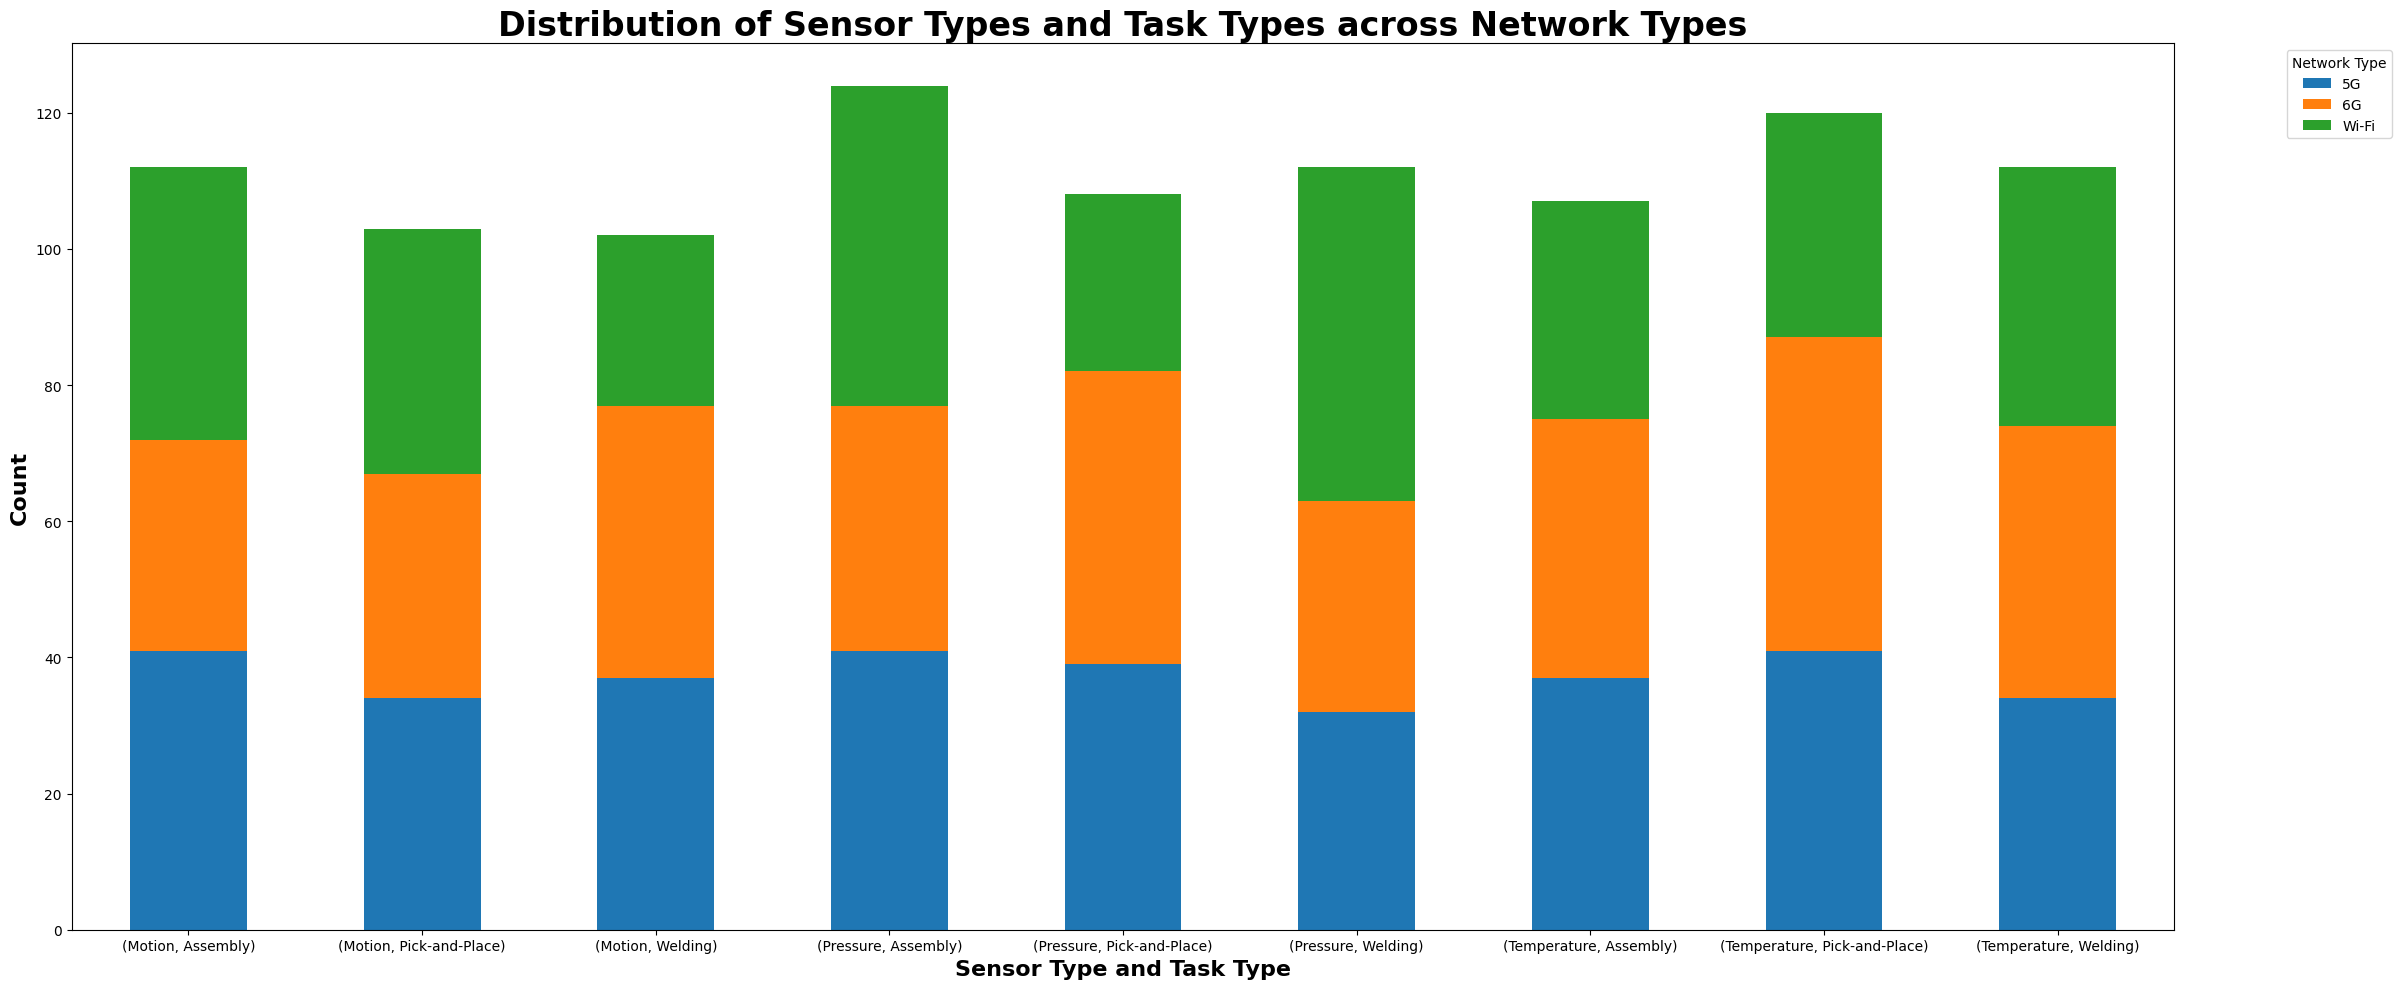

In [9]:
pd.crosstab([data["Sensor Type"], data["Task Type"]],
            [data["Network Type"]]).plot(kind="bar", stacked=True, figsize=(24,10))
plt.title("Distribution of Sensor Types and Task Types across Network Types", **common_title_settings)
plt.xlabel(**common_axis_settings, xlabel="Sensor Type and Task Type")
plt.ylabel(**common_axis_settings, ylabel="Count")
plt.xticks(rotation=0)
plt.legend(title="Network Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

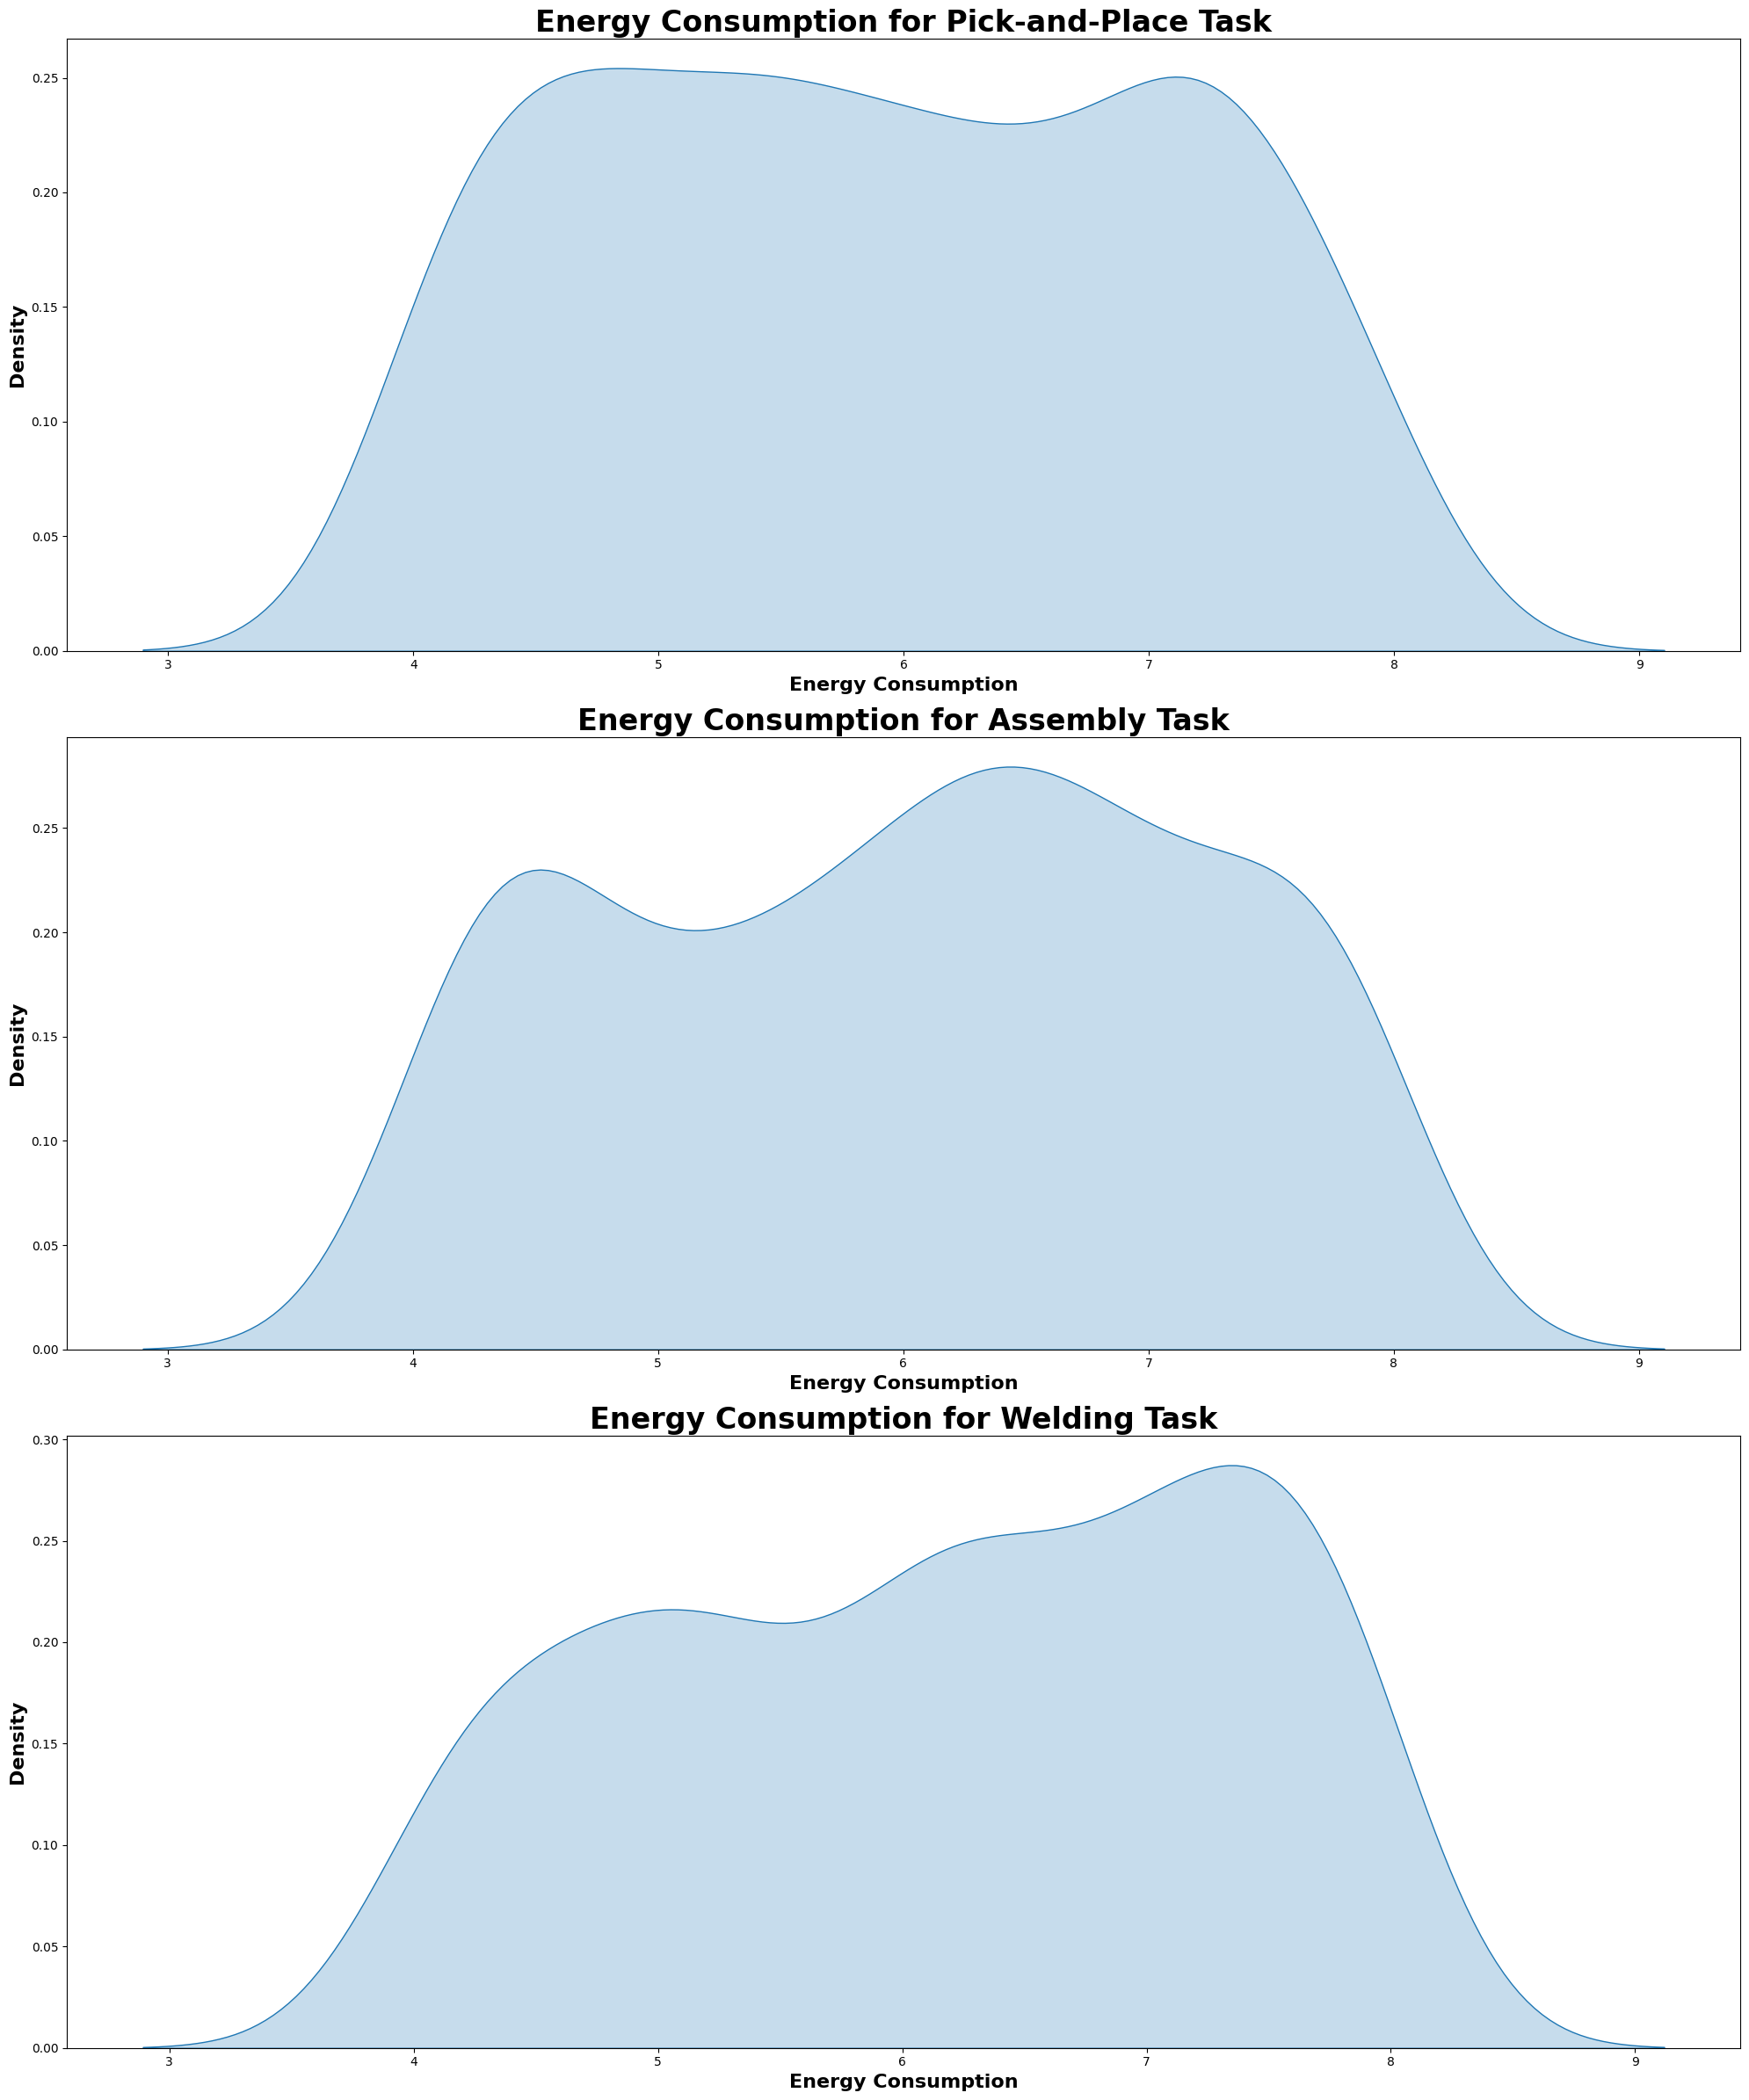

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20,24))

for i, task in enumerate(data["Task Type"].unique()):
    subdata = data[data["Task Type"] == task]
    sns.kdeplot(subdata["Energy Consumption"], ax=ax[i], fill=True)
    ax[i].set_title(f"Energy Consumption for {task} Task", **common_title_settings)
    ax[i].set_xlabel("Energy Consumption", **common_axis_settings)
    ax[i].set_ylabel("Density", **common_axis_settings)
plt.tight_layout()
plt.show()